In [120]:
# -*- coding: utf-8 -*-
"""
=====================================================================
 서울 따릉이 일별 대여량 예측 (기상 데이터 결합) - ML 파이프라인
=====================================================================
사용 방법
  1) 따릉이 데이터를 data/ 폴더에 모두 넣어주세요.
     - 서울 열린데이터광장(data.seoul.go.kr)에서 "서울시 공공자전거 이용정보(일별)"
       검색 후, 월별로 나뉘어 제공되는 CSV를 다운로드한 그대로 data/ 폴더에 모아두면 됩니다.
       (예: 따릉이_이용정보_202501.csv, 따릉이_이용정보_202502.csv, ... 파일명이 달라도
        RENTAL_FILE_GLOB 패턴에 맞기만 하면 자동으로 전부 인식해 합칩니다)
     - 12개 파일을 한꺼번에 메모리에 올리지 않고, 파일 하나씩 읽으면서 바로
       '일자별 합계'까지만 계산한 뒤 작은 결과만 모아 합치기 때문에
       1년치(수백만 행)를 받아도 메모리 문제 없이 처리됩니다.

  2) 기상 데이터는 기상자료개방포털(data.kma.go.kr) > 종관기상관측(ASOS) 일자료에서
     지점: 서울(108) 선택 후, 기간을 2025-01-01~2025-12-31로 한 번에 받으면 파일 1개로
     충분합니다 (기상 데이터는 보통 양이 적어 굳이 월별로 나눌 필요가 없습니다).
     아래 [1. 환경설정]의 WEATHER_FILE 경로를 다운로드한 파일 경로로 바꿔주세요.

  3) 파일이 하나도 없으면 자동으로 예시(가상) 데이터를 생성해서
     파이프라인이 정상 동작하는지 먼저 확인할 수 있습니다. (DEMO 모드)
     실제 데이터를 받으면 경로만 맞춰두고 그대로 재실행하면 됩니다.

  4) 필요한 패키지: pandas, numpy, scikit-learn, matplotlib, seaborn
     설치: pip install pandas numpy scikit-learn matplotlib seaborn
=====================================================================
"""

import glob
import os
import platform
import warnings

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
# from ydata_profiling import ProfileReport

warnings.filterwarnings("ignore")

# =====================================================================
# 1. 환경설정
# =====================================================================
RENTAL_DIR = "source_data/large_raw"                                                      # 따릉이 월별 CSV들이 들어있는 폴더
RENTAL_FILE_GLOB = "*공공자전거*.csv"                                           # 폴더 안에서 따릉이 파일을 찾을 패턴 (필요시 수정)
RENTAL_FILE_INTG = "./source_data/processed/서울_2023-2025_공공자전거_이용정보_통합.csv"      # 폴더 안에서 따릉이 파일을 찾을 패턴 (필요시 수정)
WEATHER_FILE = "./source_data/processed/서울기상정보/2023-2025_서울_일별_기상정보_통합.csv"  # 기상청 ASOS 일자료 CSV 경로 (보통 1개 파일로 충분)

OUTPUT_DIR = "output_data"
os.makedirs(OUTPUT_DIR, exist_ok=True)

RANDOM_STATE = 42
READ_CHUNKSIZE = 500_000   # 한 파일을 이 줄 수 단위로 끊어 읽어 메모리 사용량을 제한

def set_korean_font():
    """OS별로 설치된 한글 폰트를 찾아 matplotlib에 적용 (없으면 기본 폰트 유지)"""
    system = platform.system()
    candidates = []
    if system == "Windows":
        candidates = ["Malgun Gothic"]
    elif system == "Darwin":
        candidates = ["AppleGothic"]
    else:
        candidates = ["NanumGothic", "NanumBarunGothic", "Noto Sans CJK KR"]

    available = {f.name for f in matplotlib.font_manager.fontManager.ttflist}
    if system == "Windows":
        if "Malgun Gothic" in available:
            plt.rcParams["font.family"] = "Malgun Gothic"
            plt.rcParams["font.sans-serif"] = ["Malgun Gothic"]
        else:
            print("[안내] Windows에서 Malgun Gothic 폰트를 찾지 못했습니다. 설치 후 다시 실행하세요.")
            plt.rcParams["font.sans-serif"] = candidates
    else:
        for name in candidates:
            if name in available:
                plt.rcParams["font.family"] = name
                plt.rcParams["font.sans-serif"] = [name]
                break
        else:
            print("[안내] 한글 폰트를 찾지 못했습니다. 그래프의 한글이 깨질 수 있습니다.")
            print("       (Linux의 경우 'sudo apt-get install fonts-nanum' 후 다시 실행해보세요)")
            plt.rcParams["font.sans-serif"] = candidates
    plt.rcParams["axes.unicode_minus"] = False


set_korean_font()



In [121]:

# =====================================================================
# 2. 유틸 함수
# =====================================================================
def find_col(df, keyword):
    """컬럼명에 keyword(공백 무시)가 포함된 첫 번째 컬럼명을 반환"""
    key = keyword.replace(" ", "")
    for col in df.columns:
        if key in str(col).replace(" ", ""):
            return col
    return None


def load_rental_data_multi(file_paths, chunksize=READ_CHUNKSIZE):
    """월별로 나뉜 따릉이 원본 CSV 여러 개를 순회하며 처리한다.

    핵심 아이디어: 파일 전체(대여소 단위 수백만 행)를 한 번에 메모리에 올리지 않고,
    파일 하나당 chunksize 줄씩 끊어 읽으면서 그때그때 '일자별 합계'로 줄인다.
    각 파일에서 나온 작은 일자별 합계만 모아서 합치므로, 1년치(12개 파일)를
    한꺼번에 받아도 메모리 부담이 거의 없다.
    """
    monthly_daily_sums = []

    for path in sorted(file_paths):
        fname = os.path.basename(path)
        print(f"  - 처리 중: {fname}")

        # 헤더만 먼저 읽어 날짜/건수 컬럼이 무엇인지 파악
        header = pd.read_csv(path, encoding="cp949", nrows=0)
        print("type(header) : ", type(header))
        print("header.shape : ", header.shape)
        print("header : ", header)
        date_col = find_col(header, "대여일자") or find_col(header, "일자")
        count_col = find_col(header, "이용건수") or find_col(header, "대여건수")
        if date_col is None or count_col is None:
            raise ValueError(
                f"'{fname}' 에서 날짜/건수 컬럼을 찾지 못했습니다. "
                f"실제 컬럼명: {list(header.columns)} (find_col 검색 키워드를 조정하세요)"
            )

        # 필요한 두 컬럼만 청크 단위로 읽어 합산 -> 메모리 사용량을 크게 절감
        chunk_results = []
        for chunk in pd.read_csv(
            path, encoding="cp949", usecols=[date_col, count_col], chunksize=chunksize
        ):
            chunk[count_col] = pd.to_numeric(chunk[count_col], errors="coerce")
            chunk_results.append(chunk.groupby(date_col)[count_col].sum())

        file_daily = pd.concat(chunk_results).groupby(level=0).sum()
        monthly_daily_sums.append(file_daily)

    combined = pd.concat(monthly_daily_sums).groupby(level=0).sum()
    combined = combined.rename_axis("날짜").reset_index(name="이용건수")
    combined["날짜"] = pd.to_datetime(combined["날짜"], errors="coerce")
    return combined.sort_values("날짜").reset_index(drop=True)


In [122]:
# =====================================================================
# 3. 데이터 로드 및 일자 단위 집계
# =====================================================================
rental_files = sorted(glob.glob(os.path.join(RENTAL_DIR, RENTAL_FILE_GLOB)))
weather_exists = os.path.exists(WEATHER_FILE)
demo_mode = (len(rental_files) == 0) or (not weather_exists)

print(f"demo_mode : {demo_mode}")

if demo_mode:
    print("[DEMO 모드] 실제 데이터 파일을 찾을 수 없어 예시 데이터로 실행합니다.(구현 제외)")
else:
    print(f"[1] 따릉이 월별 파일 {len(rental_files)}개 발견 -> 순차 로드 및 일자별 집계")
    if os.path.exists(RENTAL_FILE_INTG):
        print(f"{RENTAL_FILE_INTG} exists !")
        rental_daily = pd.read_csv(RENTAL_FILE_INTG, encoding="cp949", parse_dates=["날짜"])
        rental_daily.drop(['Unnamed: 0'], axis = 1, inplace = True)
    else:
        print(f"{RENTAL_FILE_INTG} not exists !")
        rental_daily = load_rental_data_multi(rental_files)
        rental_daily.to_csv(RENTAL_FILE_INTG, encoding="cp949")
    weather_raw = pd.read_csv(WEATHER_FILE, encoding="utf-8")

print(f"\n[1] 일자별 집계 완료 - 일자 수: {rental_daily['날짜'].nunique()}, 기상 원본 행 수: {weather_raw.shape[0]}")

print( rental_daily.describe())
print( weather_raw.describe() )

print(rental_daily.head())
print(weather_raw.head())


demo_mode : False
[1] 따릉이 월별 파일 36개 발견 -> 순차 로드 및 일자별 집계
./source_data/서울_2023-2025_공공자전거_이용정보_통합.csv exists !

[1] 일자별 집계 완료 - 일자 수: 1092, 기상 원본 행 수: 1096
                                  날짜           이용건수
count                           1092    1092.000000
mean   2024-06-30 17:21:45.494505472  115363.481685
min              2023-01-01 00:00:00    3883.000000
25%              2023-09-30 18:00:00   76328.500000
50%              2024-06-29 12:00:00  118024.000000
75%              2025-04-02 06:00:00  155164.250000
max              2025-12-31 00:00:00  210999.000000
std                              NaN   48843.673562
           지점     평균기온(°C)     최저기온(°C)     최고기온(°C)    일강수량(mm)   최대 풍속(m/s)  \
count  1096.0  1096.000000  1096.000000  1096.000000  468.000000  1092.000000   
mean    108.0    14.378741    10.420529    19.013047    9.599573     4.690842   
std       0.0    10.680365    10.963646    10.660631   18.338792     1.235441   
min     108.0   -14.700000   -17.300000    -8.200000

In [123]:

# =====================================================================
# 5. 기상 데이터: 컬럼 표준화
# =====================================================================
# 키워드(검색용) -> 표준 컬럼명. 정확도를 위해 더 구체적인 키워드를 먼저 검사한다.
WEATHER_KEYWORDS = [
    ("일시", "날짜"),
    ("평균기온", "평균기온"),
    ("최고기온", "최고기온"),
    ("최저기온", "최저기온"),
    ("강수량", "강수량"),
    ("최대풍속", "최대풍속"),
    ("최저풍속", "최저풍속"),
    ("평균풍속", "평균풍속"),
    ("최저습도", "최저습도"),
    ("최고습고", "최저습도"),
    ("평균습도", "평균습도"),
    ("일조", "일조"),
    ("일사", "일사"),
    ("적설", "적설량"),
]

rename_map = {}
used_targets = set()
for keyword, target in WEATHER_KEYWORDS:
    if target in used_targets:
        continue
    col = find_col(weather_raw, keyword)
    if col is not None and col not in rename_map:
        rename_map[col] = target
        used_targets.add(target)

print("[3] 기상 데이터 컬럼 매핑 결과 (확인 후 다르면 WEATHER_KEYWORDS를 수정하세요):")
for raw_col, std_col in rename_map.items():
    print(f"      {raw_col:25s} -> {std_col}")

print("rename_map :", rename_map)

weather_std = weather_raw[list(rename_map.keys())].rename(columns=rename_map)
weather_std["날짜"] = pd.to_datetime(weather_std["날짜"], errors="coerce")

# 강수량 결측 = 비가 안 온 날 -> 0으로 처리 (관측 누락이 아니라 무강수)
if "강수량" in weather_std.columns:
    weather_std["강수량"] = weather_std["강수량"].fillna(0)
    
print("\n rename_map \n", rename_map)   
print("\n used_targets \n", used_targets)   
print("\n weather_std \n", weather_std)   


print("\n rental_daily \n", rental_daily)   
print("\n weather_std \n", weather_std)   

[3] 기상 데이터 컬럼 매핑 결과 (확인 후 다르면 WEATHER_KEYWORDS를 수정하세요):
      일시                        -> 날짜
      평균기온(°C)                  -> 평균기온
      최고기온(°C)                  -> 최고기온
      최저기온(°C)                  -> 최저기온
      일강수량(mm)                  -> 강수량
      최대 풍속(m/s)                -> 최대풍속
      평균 풍속(m/s)                -> 평균풍속
      합계 일조시간(hr)               -> 일조
      합계 일사량(MJ/m2)             -> 일사
      일 최심신적설(cm)               -> 적설량
rename_map : {'일시': '날짜', '평균기온(°C)': '평균기온', '최고기온(°C)': '최고기온', '최저기온(°C)': '최저기온', '일강수량(mm)': '강수량', '최대 풍속(m/s)': '최대풍속', '평균 풍속(m/s)': '평균풍속', '합계 일조시간(hr)': '일조', '합계 일사량(MJ/m2)': '일사', '일 최심신적설(cm)': '적설량'}

 rename_map 
 {'일시': '날짜', '평균기온(°C)': '평균기온', '최고기온(°C)': '최고기온', '최저기온(°C)': '최저기온', '일강수량(mm)': '강수량', '최대 풍속(m/s)': '최대풍속', '평균 풍속(m/s)': '평균풍속', '합계 일조시간(hr)': '일조', '합계 일사량(MJ/m2)': '일사', '일 최심신적설(cm)': '적설량'}

 used_targets 
 {'일사', '적설량', '강수량', '평균기온', '날짜', '최대풍속', '최저기온', '일조', '평균풍속', '최고기온'}

 weather_std 
              날

In [124]:

# =====================================================================
# 6. 데이터 병합
# =====================================================================
df = pd.merge(rental_daily, weather_std, on="날짜", how="inner")
print(f"\n[4] 병합 완료 - 병합된 행 수: {len(df)} (기간: {df['날짜'].min().date()} ~ {df['날짜'].max().date()})")

print("\ndf \n",df.head())



[4] 병합 완료 - 병합된 행 수: 1092 (기간: 2023-01-01 ~ 2025-12-31)

df 
           날짜   이용건수  평균기온  최고기온  최저기온  강수량  최대풍속  평균풍속   일조     일사  적설량
0 2023-01-01  38027  -0.2   3.8  -4.3  0.0   5.3   2.7  9.0  10.81  NaN
1 2023-01-02  56594  -4.5  -0.4  -7.4  0.0   4.4   2.5  9.1  11.63  NaN
2 2023-01-03  61240  -5.0   0.6  -9.0  0.0   3.9   1.8  9.1  11.77  NaN
3 2023-01-04  67705  -1.8   3.3  -5.7  0.0   4.2   1.9  8.7  10.89  NaN
4 2023-01-05  68697  -1.6   3.6  -5.6  0.0   3.2   1.6  4.7   6.09  NaN


In [ ]:
# =====================================================================
# 7. 결측치 / 이상치 처리
# =====================================================================
before = len(df)

# 기상 변수별로 결측값 처리 전략을 다르게 적용
zero_fill_cols = ["강수량", "일조", "일사", "적설량"]
for col in zero_fill_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# 온도/습도/풍속 등 연속값은 선형 보간으로 처리
interpolate_cols = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if c not in zero_fill_cols + ["이용건수"]
]
if interpolate_cols:
    df[interpolate_cols] = df[interpolate_cols].interpolate(method="linear", limit_direction="both")

# 보간 후에도 결측이 남아 있는 경우는 앞뒤 값으로 채우기
fill_cols = [c for c in df.columns if c not in ["날짜", "이용건수"]]
for col in fill_cols:
    if df[col].isna().any():
        df[col] = df[col].fillna(method="ffill").fillna(method="bfill")

# 여전히 결측이 남아 있으면 해당 행 제거
remaining_before_drop = len(df)
df = df.dropna().reset_index(drop=True)
print(f"[5] 결측치 처리: {before} -> {len(df)}건 (0 대체 + 보간 + 앞뒤 채우기)")

# 이용건수가 0 이하인 명백한 이상치(서비스 점검일 등) 제거
df = df[df["이용건수"] > 0].reset_index(drop=True)
print(f"    이용건수 0 이하 제거 후: {len(df)}건")

print("\ndf \n", df.head())

# =====================================================================
# 7-1. 날짜 파생 변수 및 시계열 특성 추가
# 7-1. 날짜 파생 변수만 추가
# =====================================================================
df["월"] = df["날짜"].dt.month
df["요일"] = df["날짜"].dt.weekday
df["is_weekend"] = df["요일"].isin([5, 6]).astype(int)
df["day_of_year"] = df["날짜"].dt.dayofyear
df["week_of_year"] = df["날짜"].dt.isocalendar().week.astype(int)

# 공휴일 정보 (2023~2025) - 네이버 달력 기준 주요 공휴일
holiday_dates = pd.to_datetime([
    "2023-01-01",
    "2023-01-21", "2023-01-22", "2023-01-23", "2023-01-24",
    "2023-03-01",
    "2023-05-05", "2023-05-27",
    "2023-06-06",
    "2023-08-15",
    "2023-09-28", "2023-09-29", "2023-09-30", "2023-10-02",
    "2023-10-03",
    "2023-10-09",
    "2023-12-25",
    "2024-01-01",
    "2024-02-09", "2024-02-10", "2024-02-11",
    "2024-03-01",
    "2024-05-05", "2024-05-06", "2024-05-15",
    "2024-06-06",
    "2024-08-15",
    "2024-09-16", "2024-09-17", "2024-09-18",
    "2024-10-03",
    "2024-10-09",
    "2024-12-25",
    "2025-01-01",
    "2025-01-28", "2025-01-29", "2025-01-30",
    "2025-03-01",
    "2025-05-05", "2025-05-06", "2025-05-13",
    "2025-06-06",
    "2025-08-15",
    "2025-09-06", "2025-09-07", "2025-09-08",
    "2025-10-03",
    "2025-10-09",
    "2025-12-25",
])
df["is_holiday"] = df["날짜"].isin(holiday_dates).astype(int)

# 시계열 특성: 이전일 이용건수, 이동평균, 전주 동일 요일 이용건수
# df = df.sort_values("날짜").reset_index(drop=True)
# df["prev_day_rental"] = df["이용건수"].shift(1)
# df["rolling_3d"] = df["이용건수"].shift(1).rolling(window=3, min_periods=1).mean()
# df["rolling_7d"] = df["이용건수"].shift(1).rolling(window=7, min_periods=1).mean()
# df["same_week_last_year"] = df["이용건수"].shift(365)

# 새로 생성한 시계열 특성으로 인한 결측값 처리
# f["prev_day_rental"] = df["prev_day_rental"].fillna(method="ffill").fillna(method="bfill")
# f["rolling_3d"] = df["rolling_3d"].fillna(method="ffill").fillna(method="bfill")
# f["rolling_7d"] = df["rolling_7d"].fillna(method="ffill").fillna(method="bfill")
# f["same_week_last_year"] = df["same_week_last_year"].fillna(df["이용건수"]).astype(float)

print("[7-1] 날짜/시계열 특성 추가 완료")


[5] 결측치 처리: 1092 -> 1092건 (0 대체 + 보간 + 앞뒤 채우기)
    이용건수 0 이하 제거 후: 1092건

df 
           날짜   이용건수  평균기온  최고기온  최저기온  강수량  최대풍속  평균풍속   일조     일사  적설량
0 2023-01-01  38027  -0.2   3.8  -4.3  0.0   5.3   2.7  9.0  10.81  0.0
1 2023-01-02  56594  -4.5  -0.4  -7.4  0.0   4.4   2.5  9.1  11.63  0.0
2 2023-01-03  61240  -5.0   0.6  -9.0  0.0   3.9   1.8  9.1  11.77  0.0
3 2023-01-04  67705  -1.8   3.3  -5.7  0.0   4.2   1.9  8.7  10.89  0.0
4 2023-01-05  68697  -1.6   3.6  -5.6  0.0   3.2   1.6  4.7   6.09  0.0
[7-1] 날짜/시계열 특성 추가 완료


numeric_cols : ['이용건수', '평균기온', '최고기온', '최저기온', '강수량', '최대풍속', '평균풍속', '일조', '일사', '적설량', '월', '요일', 'is_weekend', 'day_of_year', 'week_of_year', 'is_holiday']
<class 'pandas.core.frame.DataFrame'>


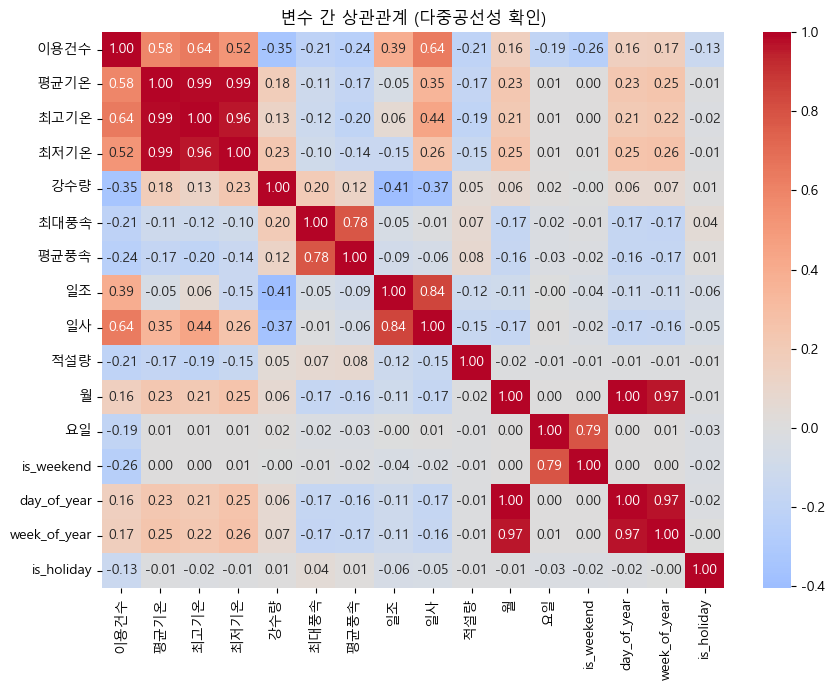

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 17/17 [00:00<?, ?it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [126]:
# =====================================================================
# 8. EDA - 상관관계 및 분포
# =====================================================================

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("numeric_cols :", numeric_cols)
corr = df[numeric_cols].corr()
print(type(df))

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("변수 간 상관관계 (다중공선성 확인)")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/01_correlation_heatmap.png", dpi=150)
plt.show()
plt.close()


# EDA Report 생성 
# profile = ProfileReport(df, title="Bike Demand Data Profile", explorative=True)
# profile.to_file("output_data/bike_demand_profile.html")


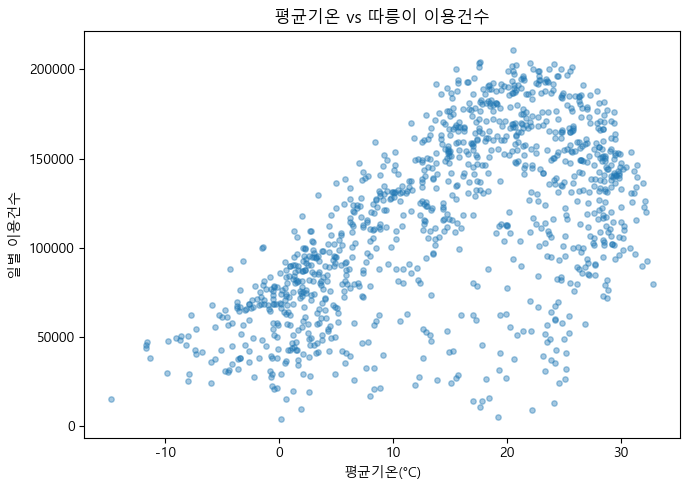

[6] EDA 그래프 저장 완료: output_data/01_correlation_heatmap.png, 02_temp_vs_rental.png

    이용건수와의 상관계수:
이용건수            1.000000
최고기온            0.642710
일사              0.637110
평균기온            0.583292
최저기온            0.517745
일조              0.393716
week_of_year    0.168451
월               0.160048
day_of_year     0.156885
is_holiday     -0.133439
요일             -0.190114
적설량            -0.207184
최대풍속           -0.214850
평균풍속           -0.244514
is_weekend     -0.255069
강수량            -0.347710


In [127]:
plt.figure(figsize=(7, 5))
plt.scatter(df["평균기온"], df["이용건수"], alpha=0.4, s=15)
plt.xlabel("평균기온(°C)")
plt.ylabel("일별 이용건수")
plt.title("평균기온 vs 따릉이 이용건수")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/02_temp_vs_rental.png", dpi=150)
plt.show()
plt.close()

print(f"[6] EDA 그래프 저장 완료: {OUTPUT_DIR}/01_correlation_heatmap.png, 02_temp_vs_rental.png")
print("\n    이용건수와의 상관계수:")
print(corr["이용건수"].sort_values(ascending=False).to_string())


In [ ]:
# =====================================================================
# 9. 변수 선택 
# ### 월별지수(추세) 피처 추가 (제외) 
# =====================================================================
# df["월"] = df["날짜"].dt.month
# df["월간지수"] = df["월"] - df["월"].min()  # 가장 이른 월을 0으로

# 다중공선성이 높은 변수 중 대표값만 선택 (기온군 -> 평균기온, 습도군 -> 평균습도 등)
# candidate_features = ["평균기온", "강수량", "평균풍속", "평균습도", "일사", "월간지수"]
candidate_features = ["평균기온", "강수량", "평균풍속", "평균습도", "일사",
    "월", "요일", "is_weekend", "day_of_year", "week_of_year", "is_holiday",
]
features = [c for c in candidate_features if c in df.columns]
print(f"\n[7] 최종 사용 독립변수: {features}")

X = df[features]
y = df["이용건수"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)



[7] 최종 사용 독립변수: ['평균기온', '강수량', '평균풍속', '일사', '월', '요일', 'is_weekend', 'day_of_year', 'week_of_year', 'is_holiday']


In [ ]:
# =====================================================================
# 10. 모델 학습 및 비교
# =====================================================================
results = []

def evaluate(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    results.append({"모델": name, "R2": r2, "MSE": mse, "RMSE": rmse, "MAE": mae})
    print(f"  - {name:28s} R2={r2:.4f}  RMSE={rmse:,.1f}  MAE={mae:,.1f}")

print("\n[8] 모델 학습 및 평가")

# --- 모델 1: 단순 선형회귀 ---
model1 = LinearRegression().fit(X_train, y_train)
pred1 = model1.predict(X_test)
evaluate("선형회귀", y_test, pred1)

# --- 모델 2: 랜덤포레스트 (기본 파라미터) ---
model2 = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
model2.fit(X_train[features], y_train)
pred2 = model2.predict(X_test[features])
evaluate("랜덤포레스트(기본)", y_test, pred2)

# --- 모델 3: 의사결정트리 (기본 파라미터) ---
from sklearn.tree import DecisionTreeRegressor
model3 = DecisionTreeRegressor(random_state=RANDOM_STATE, max_depth=8)
model3.fit(X_train[features], y_train)
pred3 = model3.predict(X_test[features])
evaluate("결정트리(기본)", y_test, pred3)

best_model = model2
pred4 = pred2



[8] 모델 학습 및 평가
  - 선형회귀                         R2=0.7202  RMSE=24,297.2  MAE=18,548.9
  - 랜덤포레스트(기본)                   R2=0.8887  RMSE=15,326.2  MAE=11,609.2
  - 결정트리(기본)                     R2=0.8144  RMSE=19,790.5  MAE=14,492.9


In [131]:

# =====================================================================
# 11. 결과 비교표 출력 및 저장
# =====================================================================
result_df = pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)
print("\n[9] 모델 비교 결과 (R2 기준 정렬)")
print(result_df.to_string(index=False))
result_df.to_csv(f"{OUTPUT_DIR}/model_comparison.csv", index=False, encoding="utf-8-sig")



[9] 모델 비교 결과 (R2 기준 정렬)
        모델       R2          MSE         RMSE          MAE
랜덤포레스트(기본) 0.888669 2.348936e+08 15326.238867 11609.248767
  결정트리(기본) 0.814366 3.916630e+08 19790.478303 14492.926725
      선형회귀 0.720194 5.903536e+08 24297.192296 18548.902201


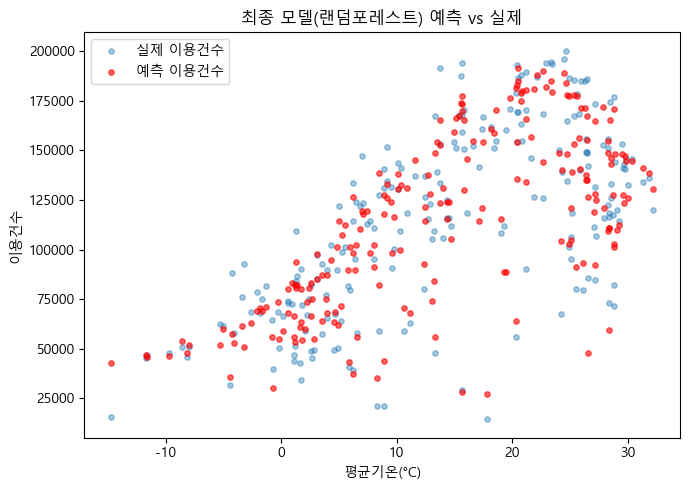

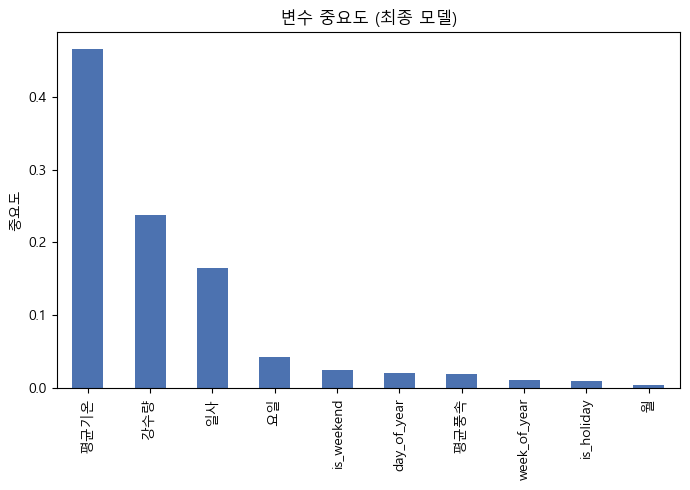


[10] 최종 그래프 저장 완료: output_data/03_final_model_fit.png, 04_feature_importance.png

변수 중요도:
평균기온            0.465141
강수량             0.236982
일사              0.165190
요일              0.042524
is_weekend      0.025157
day_of_year     0.021202
평균풍속            0.018786
week_of_year    0.011516
is_holiday      0.009685
월               0.003818

모든 결과물이 'output_data/' 폴더에 저장되었습니다.


In [132]:
# =====================================================================
# 12. 최종(최적) 모델 결과 시각화
# =====================================================================
plt.figure(figsize=(7, 5))
plt.scatter(X_test["평균기온"], y_test, alpha=0.4, s=15, label="실제 이용건수")
plt.scatter(X_test["평균기온"], pred4, alpha=0.6, s=15, color="red", label="예측 이용건수")
plt.xlabel("평균기온(°C)")
plt.ylabel("이용건수")
plt.title("최종 모델(랜덤포레스트) 예측 vs 실제")
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/03_final_model_fit.png", dpi=150)
plt.show()
plt.close()

importances = pd.Series(best_model.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(7, 5))
importances.plot(kind="bar", color="#4C72B0")
plt.ylabel("중요도")
plt.title("변수 중요도 (최종 모델)")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/04_feature_importance.png", dpi=150)
plt.show()
plt.close()

print(f"\n[10] 최종 그래프 저장 완료: {OUTPUT_DIR}/03_final_model_fit.png, 04_feature_importance.png")
print("\n변수 중요도:")
print(importances.to_string())

print(f"\n모든 결과물이 '{OUTPUT_DIR}/' 폴더에 저장되었습니다.")
if demo_mode:
    print("\n※ 지금 실행된 결과는 DEMO(가상) 데이터 기준입니다.")
    print("   실제 데이터를 받아 RENTAL_FILE / WEATHER_FILE 경로를 수정한 뒤 다시 실행하세요.")


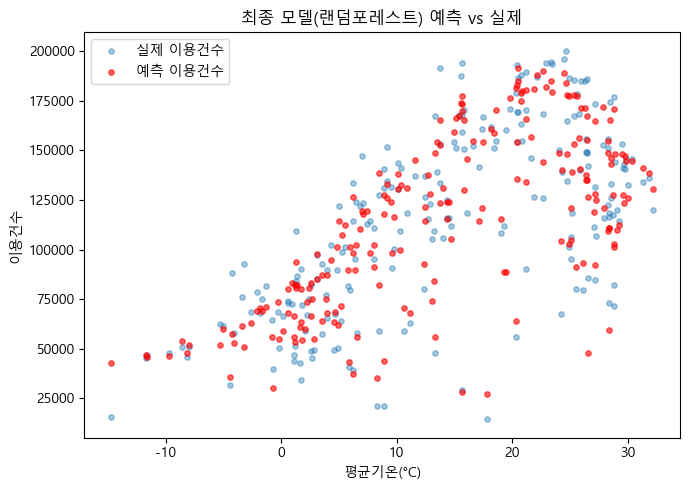

In [133]:
plt.figure(figsize=(7, 5))
plt.scatter(X_test["평균기온"], y_test, alpha=0.4, s=15, label="실제 이용건수")
plt.scatter(X_test["평균기온"], pred4, alpha=0.6, s=15, color="red", label="예측 이용건수")
plt.xlabel("평균기온(°C)")
plt.ylabel("이용건수")
plt.title("최종 모델(랜덤포레스트) 예측 vs 실제")
plt.legend()
plt.tight_layout()
##plt.savefig(f"{OUTPUT_DIR}/03_final_model_fit.png", dpi=150)
plt.show()
plt.close()